<a href="https://colab.research.google.com/github/reddoma742/DTQEM-Negative-Time-Non-locality/blob/main/DTQEM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

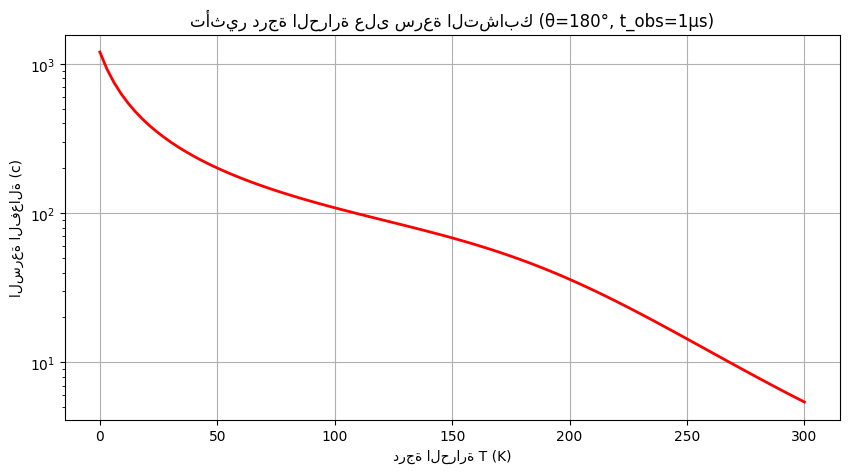

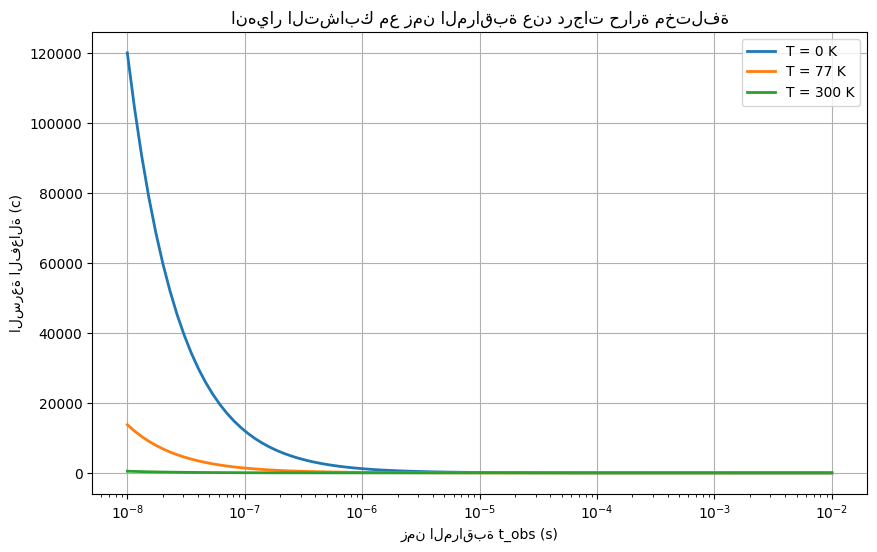

تأثير درجة الحرارة وزمن المراقبة على السرعة الفعالة (θ=180°)
مسافة = 11000 km, v/c = 0.60
----------------------------------------------------------------------
 T (K) | t_obs (s) |  Γ(T) (1/s) | K_eff   | t_eff (s)   | v_eff (c)
----------------------------------------------------------------------
   0 | 1.0e-09 | 1.00e+03 | 1.000e+00 | 3.06e-08 | 1.20e+06
   0 | 1.0e-06 | 1.00e+03 | 9.990e-01 | 3.06e-05 | 1.20e+03
   0 | 1.0e-03 | 1.00e+03 | 3.679e-01 | 1.93e-02 | 1.90e+00
  77 | 1.0e-09 | 8.72e+03 | 1.000e+00 | 2.67e-07 | 1.38e+05
  77 | 1.0e-06 | 8.72e+03 | 9.913e-01 | 2.65e-04 | 1.38e+02
  77 | 1.0e-03 | 8.72e+03 | 1.632e-04 | 3.06e-02 | 1.20e+00
 300 | 1.0e-09 | 2.50e+05 | 9.998e-01 | 7.64e-06 | 4.80e+03
 300 | 1.0e-06 | 2.50e+05 | 7.788e-01 | 6.76e-03 | 5.43e+00
 300 | 1.0e-03 | 2.50e+05 | 2.750e-109 | 3.06e-02 | 1.20e+00


In [1]:

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# النموذج المتكامل النهائي (الإصدار 2.0) مع معامل تخميد حراري
# ----------------------------------------------------------------------

class ModeleIntricationThermique:
    def __init__(self,
                 distance_km=11000,          # مسافة (km)
                 v_rel_c=0.6,                # سرعة كل جسيم (بالنسبة لـ c)
                 t_Planck=5.391e-44,         # حد بلانك (ثانية)
                 # معاملات التخميد الحراري
                 Gamma0=1e3,                 # Γ₀ (1/s)  فك الترابط عند الصفر المطلق
                 a=1e2,                      # معامل T (1/s/K)
                 b=1e-5,                    # معامل T^3 (1/s/K^3)
                 c=1e-12):                  # معامل T^7 (1/s/K^7)
        self.d = distance_km
        self.c = 299792.458                  # km/s
        self.v = v_rel_c * self.c
        self.t_Planck = t_Planck
        self.Gamma0 = Gamma0
        self.a = a
        self.b = b
        self.c_coef = c

    def alpha(self, theta_deg):
        """α(θ) = sin(θ/2)"""
        return np.sin(np.radians(theta_deg) / 2.0)

    def vitesse_rel(self, theta_deg):
        """سرعة التباعد النسبية الكلاسيكية (km/s)"""
        return 2 * self.v * self.alpha(theta_deg)

    def tr_classique(self, theta_deg):
        """الزمن الكلاسيكي لقطع المسافة (ثانية)"""
        vr = self.vitesse_rel(theta_deg)
        if vr <= 0:
            return np.inf
        return self.d / vr

    def Gamma(self, T):
        """معامل التخميد المعتمد على درجة الحرارة"""
        return self.Gamma0 + self.a * T + self.b * (T**3) + self.c_coef * (T**7)

    def K_eff(self, T, t_obs):
        """مفتاح المراقبة الفعال (قيمة مستمرة بين 0 و 1)"""
        if t_obs <= 0:
            return 1.0
        gamma = self.Gamma(T)
        return np.exp(-gamma * t_obs)

    def teff(self, theta_deg, T, t_obs=0.0):
        """الزمن الفعال (مع حد بلانك)"""
        tr = self.tr_classique(theta_deg)
        if np.isinf(tr):
            return np.inf
        a_val = self.alpha(theta_deg)
        K = self.K_eff(T, t_obs)
        te = tr * (1 - a_val * K)
        if te < self.t_Planck:
            te = self.t_Planck
        return te

    def vitesse_eff(self, theta_deg, T, t_obs=0.0):
        """السرعة الفعالة (km/s)"""
        te = self.teff(theta_deg, T, t_obs)
        if np.isinf(te):
            return 0.0
        return self.d / te

    def vitesse_eff_c(self, theta_deg, T, t_obs=0.0):
        """السرعة الفعالة بوحدة c"""
        return self.vitesse_eff(theta_deg, T, t_obs) / self.c

# ----------------------------------------------------------------------
# تجربة النموذج مع تأثير درجة الحرارة وزمن المراقبة
# ----------------------------------------------------------------------

if __name__ == "__main__":
    # إنشاء نموذج بقيم افتراضية للمعاملات (يمكن تعديلها)
    modele = ModeleIntricationThermique(
        distance_km=11000,
        v_rel_c=0.6,
        t_Planck=5.391e-44,
        Gamma0=1e3,     # فك ترابط أساسي
        a=1e2,          # مساهمة خطية في T
        b=1e-5,         # مساهمة T^3
        c=1e-12         # مساهمة T^7
    )

    theta = 180.0      # أقصى تشابك
    t_obs_fixed = 1e-6 # زمن مراقبة ثابت (1 ميكروثانية)

    # 1. تأثير درجة الحرارة على السرعة الفعالة
    T_range = np.linspace(0, 300, 100)  # من 0 إلى 300 كلفن
    v_c_T = []
    for T in T_range:
        v = modele.vitesse_eff_c(theta, T, t_obs=t_obs_fixed)
        v_c_T.append(v)

    plt.figure(figsize=(10,5))
    plt.plot(T_range, v_c_T, 'r-', linewidth=2)
    plt.xlabel('درجة الحرارة T (K)')
    plt.ylabel('السرعة الفعالة (c)')
    plt.title('تأثير درجة الحرارة على سرعة التشابك (θ=180°, t_obs=1µs)')
    plt.grid(True)
    plt.yscale('log')
    plt.show()

    # 2. تأثير زمن المراقبة عند درجات حرارة مختلفة
    t_obs_range = np.logspace(-8, -2, 100)
    temperatures = [0, 77, 300]  # الصفر المطلق، النيتروجين السائل، الغرفة
    plt.figure(figsize=(10,6))
    for T in temperatures:
        v_list = []
        for t_obs in t_obs_range:
            v = modele.vitesse_eff_c(theta, T, t_obs)
            v_list.append(v)
        plt.semilogx(t_obs_range, v_list, label=f'T = {T} K', linewidth=2)
    plt.xlabel('زمن المراقبة t_obs (s)')
    plt.ylabel('السرعة الفعالة (c)')
    plt.title('انهيار التشابك مع زمن المراقبة عند درجات حرارة مختلفة')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 3. جدول قيم عند θ=180° لدرجات حرارة وأزمنة مراقبة محددة
    print("="*70)
    print("تأثير درجة الحرارة وزمن المراقبة على السرعة الفعالة (θ=180°)")
    print(f"مسافة = {modele.d} km, v/c = {modele.v/modele.c:.2f}")
    print("-"*70)
    print(" T (K) | t_obs (s) |  Γ(T) (1/s) | K_eff   | t_eff (s)   | v_eff (c)")
    print("-"*70)
    test_T = [0, 77, 300]
    test_t_obs = [1e-9, 1e-6, 1e-3]
    for T in test_T:
        gamma = modele.Gamma(T)
        for t_obs in test_t_obs:
            K = modele.K_eff(T, t_obs)
            te = modele.teff(theta, T, t_obs)
            vc = modele.vitesse_eff_c(theta, T, t_obs)
            print(f"{T:4} | {t_obs:.1e} | {gamma:.2e} | {K:.3e} | {te:.2e} | {vc:.2e}")
    print("="*70)